In [7]:
import pandas as pd
from datetime import datetime
import numpy as np
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt

## Read training and test datasets

In [8]:
# helper function for reading datatset
def read_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d') # convert it to datatime

    return df

In [9]:
df_train = read_data('data/kospi_train.csv')
df_test = read_data('data/kospi_test.csv')

len(df_train), len(df_test)

(986, 244)

In [10]:
# the training dataset has daily KOSPI index from 2019 to 2022
df_train

,Date,Open,Low,High,Close,Volume
0,2019-01-02,2050.550049,2004.270020,2053.449951,2010.000000,326400
1,2019-01-03,2011.810059,1991.650024,2014.719971,1993.699951,428000
2,2019-01-04,1992.400024,1984.530029,2011.560059,2010.250000,409000
3,2019-01-07,2034.239990,2030.900024,2048.060059,2037.099976,440200
4,2019-01-08,2038.680054,2023.589966,2042.699951,2025.270020,397800
...,...,...,...,...,...,...
981,2022-12-23,2325.860107,2311.899902,2333.080078,2313.689941,367000
982,2022-12-26,2312.540039,2304.199951,2321.919922,2317.139893,427600
983,2022-12-27,2327.520020,2321.479980,2335.989990,2332.790039,448300
984,2022-12-28,2296.449951,2276.899902,2296.449951,2280.449951,405700


In [11]:
# the test dataset has daily KOSPI index in 2023
df_test

,Date,Open,Low,High,Close,Volume
0,2023-01-02,2249.949951,2222.370117,2259.879883,2225.669922,346100
1,2023-01-03,2230.979980,2180.669922,2230.979980,2218.679932,410000
2,2023-01-04,2205.979980,2198.820068,2260.060059,2255.979980,412700
3,2023-01-05,2268.199951,2252.969971,2281.389893,2264.649902,430800
4,2023-01-06,2253.399902,2253.270020,2300.620117,2289.969971,398300
...,...,...,...,...,...,...
239,2023-12-21,2598.370117,2587.159912,2610.810059,2600.020020,578300
240,2023-12-22,2617.719971,2599.510010,2621.370117,2599.510010,466000
241,2023-12-26,2609.439941,2594.649902,2612.139893,2602.590088,439500
242,2023-12-27,2599.350098,2590.080078,2613.500000,2613.500000,349700


## Part 1. Train regression models to predict the next day's `close` using `Open`, `Low`, `High`, `Close`, `Volume` of previous days as predictors using *only* df_train. Cross-validate to select the best model. Evaluate the accuracy of your model using `df_test`.


In [ ]:
# GOOD LUCK

# Assume df_train and df_test are preloaded
def create_features(df):
    # Shift features to use previous day's data to predict next day's Close
    df_feat = df[['Open', 'High', 'Low', 'Close', 'Volume']].shift(-1)
    df_feat['Target'] = df['Close']  # today's Close is the target
    df_feat = df_feat.dropna()
    return df_feat

# Prepare features
train_feat = create_features(df_train)
test_feat = create_features(df_test)

X_train = train_feat.drop(columns='Target')
y_train = train_feat['Target']
X_test = test_feat.drop(columns='Target')
y_test = test_feat['Target']

# Standardize features (optional but useful for some models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'SVR': SVR(),
    'GradientBoosting': GradientBoostingRegressor(),
}

best_score = float('inf')
best_model = None
best_name = ""
tscv = TimeSeriesSplit(n_splits=5)

# Store scaled features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Cross-validation to find the best model
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=tscv, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    avg_rmse = rmse_scores.mean()
    print(f"{name} CV RMSE: {avg_rmse:.4f}")
    
    if avg_rmse < best_score:
        best_score = avg_rmse
        best_model = model
        best_name = name

print(f"\nSelected best model: {best_name} with CV RMSE: {best_score:.4f}")

# Train best model on full training set
best_model.fit(X_train_scaled, y_train)
preds = best_model.predict(X_test_scaled)

# Evaluate on test set
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")


LinearRegression CV RMSE: 19.1429
RandomForest CV RMSE: 141.7198
SVR CV RMSE: 405.0790
GradientBoosting CV RMSE: 141.9430

Selected best model: LinearRegression with CV RMSE: 19.1429
Test RMSE: 14.3887
Test R²: 0.9734


## Part 2. Extend the regression model by adding some extra features of your choice. You can use any statistics publicly available. 

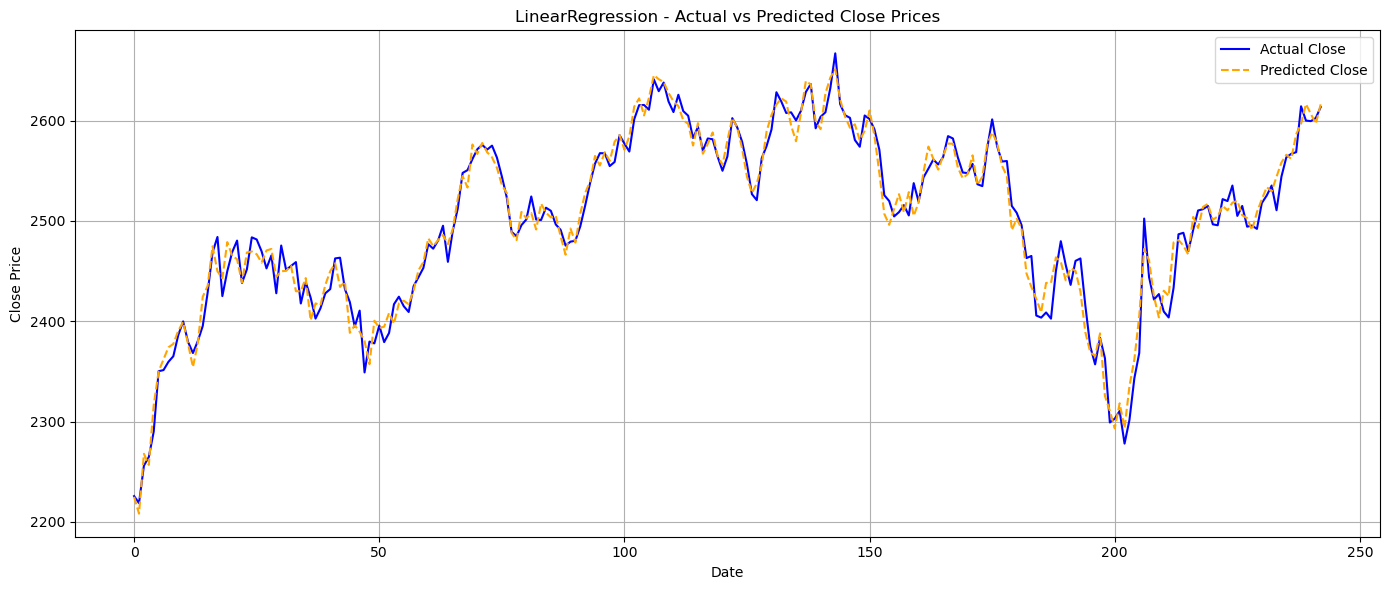

In [13]:
# GOOD LUCK

plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label='Actual Close', color='blue')
plt.plot(y_test.index, preds, label='Predicted Close', color='orange', linestyle='--')

plt.title(f'{best_name} - Actual vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

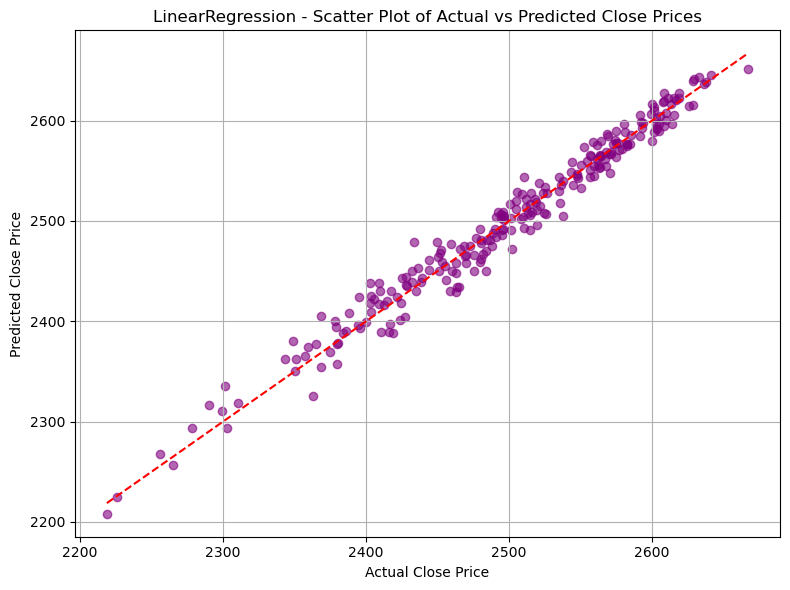

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line

plt.title(f'{best_name} - Scatter Plot of Actual vs Predicted Close Prices')
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()